# Xây dựng mô hình từ giải thuật SVM trên dữ liệu các con thú trong rừng. Dữ liệu lấy từ https://www.kaggle.com/code/kareemellithy/animal-condition-predict-svm-knn

# 1. Import thư viện & nạp dữ liệu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [2]:
# Đọc dữ liệu từ file CSV
data = pd.read_csv("./data/data.csv")

# Xem 5 dòng đầu tiên
print(data.head())

  AnimalName symptoms1             symptoms2 symptoms3    symptoms4  \
0        Dog     Fever              Diarrhea  Vomiting  Weight loss   
1        Dog     Fever              Diarrhea  Coughing    Tiredness   
2        Dog     Fever              Diarrhea  Coughing     Vomiting   
3        Dog     Fever  Difficulty breathing  Coughing     Lethargy   
4        Dog     Fever              Diarrhea  Coughing     Lethargy   

     symptoms5 Dangerous  
0  Dehydration       Yes  
1        Pains       Yes  
2     Anorexia       Yes  
3     Sneezing       Yes  
4     Blue Eye       Yes  


In [3]:
# Thông tin tổng quan về kiểu dữ liệu và số null
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871 entries, 0 to 870
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   AnimalName  871 non-null    object
 1   symptoms1   871 non-null    object
 2   symptoms2   871 non-null    object
 3   symptoms3   871 non-null    object
 4   symptoms4   871 non-null    object
 5   symptoms5   871 non-null    object
 6   Dangerous   869 non-null    object
dtypes: object(7)
memory usage: 47.8+ KB
None


In [4]:
# Thống kê mô tả cho các cột số
print(data.describe())

       AnimalName symptoms1 symptoms2 symptoms3    symptoms4 symptoms5  \
count         871       871       871       871          871       871   
unique         46       232       230       229          217       203   
top     Buffaloes     Fever  Diarrhea  Coughing  Weight loss     Pains   
freq          129       257       119        95          117        99   

       Dangerous  
count        869  
unique         2  
top          Yes  
freq         849  


In [6]:
# Đếm số lượng giá trị thiếu ở mỗi cột
print(data.isna().sum())

AnimalName    0
symptoms1     0
symptoms2     0
symptoms3     0
symptoms4     0
symptoms5     0
Dangerous     2
dtype: int64


# 2. Phân tích & loại bỏ features không liên quan


* **AnimalName**

  * Là tên loài động vật (Dog, Cat…).
  * Đây là *categorical feature hữu ích*, có ảnh hưởng đến khả năng mắc bệnh khác nhau → **GIỮ LẠI**.

* **symptoms1 → symptoms5**

  * Mỗi cột chứa mô tả triệu chứng dạng text (Fever, Vomiting, Coughing…).
  * Đây là *features chính* của bài toán vì mô tả tình trạng bệnh → **GIỮ LẠI**.
  * Tuy nhiên, cần **encoding** (Label Encoding hoặc One-Hot) trước khi đưa vào mô hình.

* **Dangerous** (label)

  * Biến mục tiêu (Yes/No).
  * Dùng để huấn luyện và đánh giá mô hình → **GIỮ LẠI**.


**Kết luận loại bỏ**

* Dataset **không chứa cột nào vô nghĩa**, ID, index, hoặc non-informative.
* → **Không cần loại bỏ features**.
* Thay vào đó, cần **encode toàn bộ các cột dạng text**.

# 3. Tiền xử lý dữ liệu

## 3.1 Xử lý giá trị trùng lắp

In [7]:
# Handle duplicates
duplicate_rows_data = data[data.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (28, 7)


In [10]:
data.drop_duplicates(inplace=True)
print(data.shape)

(843, 7)


## 3.2 Loại bỏ giá trị null

In [12]:
data.dropna(inplace=True)
print(data.shape)

(841, 7)


## 3.3 Mã hoá biến phân loại 

In [13]:
# Chọn cột cần encode
categorical_cols = ['AnimalName', 'symptoms1', 'symptoms2', 'symptoms3', 'symptoms4', 'symptoms5']

# One-Hot Encode
data_encoded = pd.get_dummies(data, columns=categorical_cols)

# Encode nhãn
data_encoded['Dangerous'] = data_encoded['Dangerous'].map({'Yes': 1, 'No': 0})

data_encoded.head()

,Dangerous,AnimalName_Birds,AnimalName_Black-tailed deer,AnimalName_Buffaloes,AnimalName_Cattle,AnimalName_Chicken,AnimalName_Deer,AnimalName_Dog,AnimalName_Dogs,AnimalName_Donkey,...,symptoms5_restless movement,symptoms5_slow growth,symptoms5_sudden death,symptoms5_swollen abdomen,symptoms5_trembling,symptoms5_twisted neck,symptoms5_urination problem,symptoms5_weakness,symptoms5_ increased passing gas,symptoms5_ pain and bloating
0,1,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


# 4. Chia tập train/test

In [15]:
# Biến đầu vào X và nhãn y
X = data_encoded.drop('Dangerous', axis=1)
y = data_encoded['Dangerous']

# Chia train/test (vd: 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test :", X_test.shape)


Kích thước tập train: (672, 1153)
Kích thước tập test : (169, 1153)


# 5 Áp dụng mô hình SVM

chuẩn hóa dữ liệu

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
clf = SVC()
clf.fit(X_train, y_train)

train_acc = clf.score(X_train,y_train)
val_acc = clf.score(X_test,y_test)
print('Training accuracy: {}'.format(train_acc))
print('Validation accuracy: {}'.format(val_acc))

Training accuracy: 0.9970238095238095
Validation accuracy: 0.9763313609467456


# 6. Sử dụng GridSearchCV để tìm tham số tối ưu cho mô hình SVM

In [18]:
param_grid = {
    'C': [1, 10, 50],
    'gamma': ['scale',  0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

print("Best parameters found:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters found: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation score: 0.9851190476190478


Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Test accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00       165

    accuracy                           1.00       169
   macro avg       1.00      1.00      1.00       169
weighted avg       1.00      1.00      1.00       169


Confusion matrix:
 [[  4   0]
 [  0 165]]
AUC: 1.0


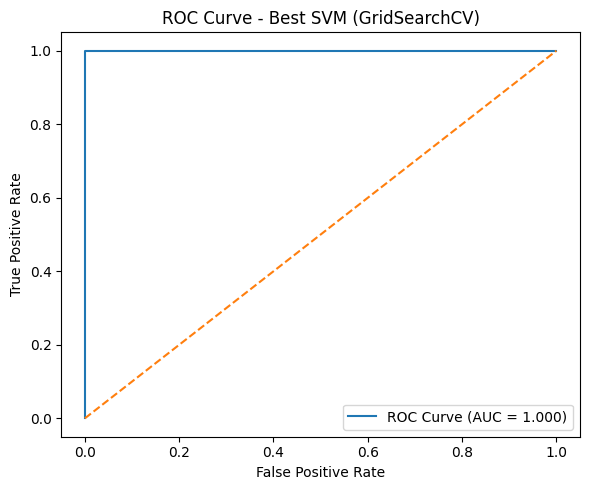

In [19]:
# Lấy bộ tham số tối ưu từ GridSearch
best_params = grid.best_params_
print("Best params:", best_params)

# Tạo lại mô hình SVM với probability=True để dùng predict_proba
best_svm = SVC(
    **best_params,        # gồm C, gamma, kernel (nếu có trong param_grid)
    probability=True      # thêm dòng này để dùng được predict_proba
)

# Huấn luyện lại trên tập train đã scale
best_svm.fit(X_train_scaled, y_train)

# ---------------------------
#  Đánh giá trên tập test
# ---------------------------
y_pred = best_svm.predict(X_test_scaled)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

# ---------------------------
#  ROC Curve + AUC
# ---------------------------
# Xác suất dự đoán lớp 1 (bị tiểu đường)
y_prob = best_svm.predict_proba(X_test_scaled)[:, 1]

# Tính FPR, TPR cho các ngưỡng threshold khác nhau
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)
print("AUC:", auc_value)

# Vẽ ROC
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # đường chéo random
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best SVM (GridSearchCV)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Kết thúc